In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rkhs_epsilon import RKHSEpsilonMachine

Factorial Run Process (FRP) is a generator $\epsilon$-machine which has infinitely countable number of causal states. Consider the following setting:
 - alphabet $\mathcal{X} = \{ 0, 1 \}$
 - causal states $\mathcal{S} = \{ \sigma_0, \sigma_1, \dots \}$
 - morphs $\delta (1 \mid \sigma_n ) = \frac{1}{n+2}$ and $\delta (0 \mid \sigma_n ) = \frac{n+1}{n+2}$
 - transitions $\tau (\sigma_n , 1) = \sigma_{n+1}$ and $\tau (\sigma_n , 0) = \sigma_0$

Think of it as a generalization of the Even Process, where blocks of observed 1's are constrained to have an even length. Here, in contrast, blocks of observed 1's can hvae any length, however long blocks are exponentially rare. A causal state $\sigma_n$ represents "*an observer has seen a block of n 1's since the last 0*".

In [2]:
def factorial_run_process(N=2000, seed=2137):
    rng = np.random.default_rng(seed)
    series = np.zeros(N, dtype=int)
    states = np.zeros(N, dtype=int)

    state = 0  # start in sigma_0
    for t in range(N):
        states[t] = state
        p_one = 1.0 / (state + 2)
        if rng.random() < p_one:
            series[t] = 1
            state += 1
        else:
            series[t] = 0
            state = 0

    return series, states


As we can see on the below figure, it spends much of the time in $\sigma_0$ with rare spikes. It's stationary distribution is given by (TBD: derive it)
$$
\mu (\sigma_n) = \frac{1}{(n+1)!(e-1)}
$$

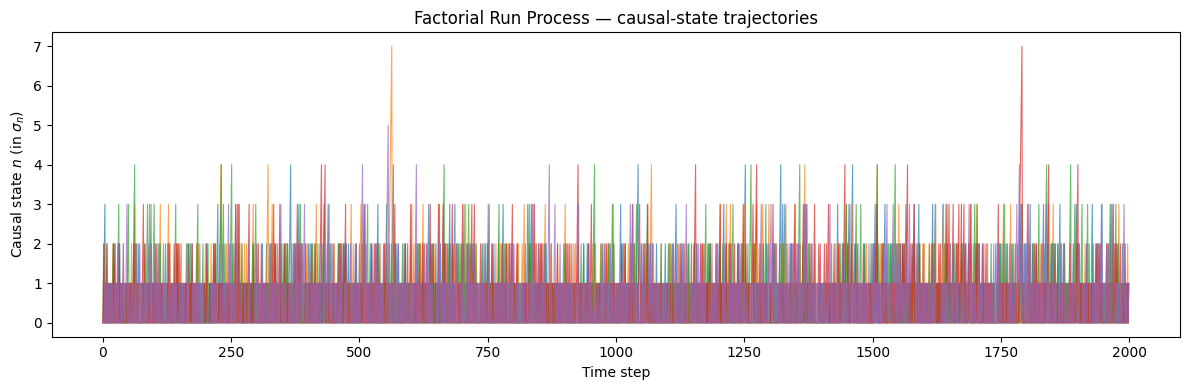

In [3]:
n_traj = 5
seeds = [0, 1, 2, 3, 4]

fig, ax = plt.subplots(figsize=(12, 4))

for i, seed in enumerate(seeds):
    series_i, states_i = factorial_run_process(N=2000, seed=seed)
    ax.plot(states_i, alpha=0.7, linewidth=0.8, label=f"traj {i+1}")

ax.set_xlabel("Time step")
ax.set_ylabel("Causal state $n$ (in $\\sigma_n$)")
ax.set_title("Factorial Run Process — causal-state trajectories")
plt.tight_layout()
plt.show()


Can a kernel $\epsilon$-machine discover increasing number of causal states as observed length $N$ increases? How well it approximates statistical complexity $\hat{C}_\mu$ (true $C_\mu \approx 1.14$ bits - TBD: derive it).

Series 1/10 done
Series 2/10 done
Series 3/10 done
Series 4/10 done
Series 5/10 done
Series 6/10 done
Series 7/10 done
Series 8/10 done
Series 9/10 done
Series 10/10 done


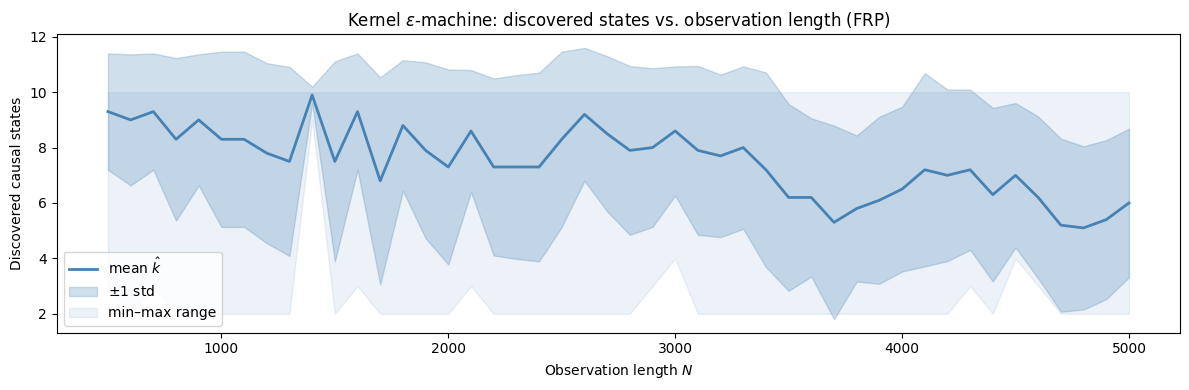

In [4]:
n_series = 10
N = 5000
ks = np.arange(500, N + 1, 100)
seeds = range(n_series)

# results[i, j] = n_states_found for series i at observation length ks[j]
results = np.zeros((n_series, len(ks)), dtype=int)

for i, seed in enumerate(seeds):
    series_i, _ = factorial_run_process(N=N, seed=seed)
    for j, k in enumerate(ks):
        model = RKHSEpsilonMachine(clustering_method="kmeans")
        model.fit(series_i[:k])
        results[i, j] = model.n_states_found_
    print(f"Series {i+1}/{n_series} done")

mean_states = results.mean(axis=0)
std_states  = results.std(axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ks, mean_states, color="steelblue", linewidth=2, label="mean $\\hat{k}$")
ax.fill_between(
    ks,
    mean_states - std_states,
    mean_states + std_states,
    alpha=0.25,
    color="steelblue",
    label="$\\pm 1$ std",
)
ax.fill_between(
    ks,
    results.min(axis=0),
    results.max(axis=0),
    alpha=0.10,
    color="steelblue",
    label="min–max range",
)
ax.set_xlabel("Observation length $N$")
ax.set_ylabel("Discovered causal states")
ax.set_title("Kernel $\\epsilon$-machine: discovered states vs. observation length (FRP)")
ax.legend()
plt.tight_layout()
plt.show()
